In [ ]:
# Task 1: Dataset Exploration

# Load dataset
from ucimlrepo import fetch_ucirepo
import pandas as pd
banknote_authentication = fetch_ucirepo(id=267)
X = banknote_authentication.data.features
y = banknote_authentication.data.targets
df = pd.concat([X, y], axis=1)

# Display the first five samples.
print("First Five Samples:\n",df.head())

# Determine dataset dimensions
print("\nDataset Dimensions:\n",df.shape)

# Identify missing values
print("\nMissing Values:\n",df.isnull().sum())

# Display descriptive statistics
print("\nDescriptive Statistics:\n",df.describe())

First Five Samples:
    variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Dimensions:
 (1372, 5)

Missing Values:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Descriptive Statistics:
           variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625    

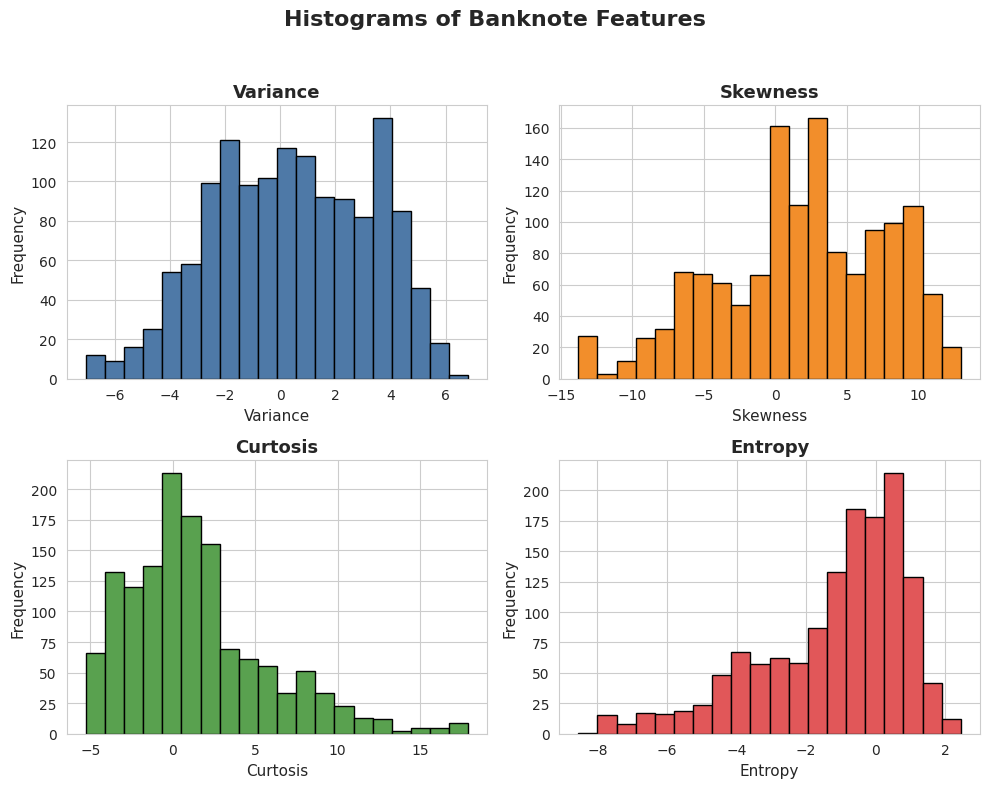

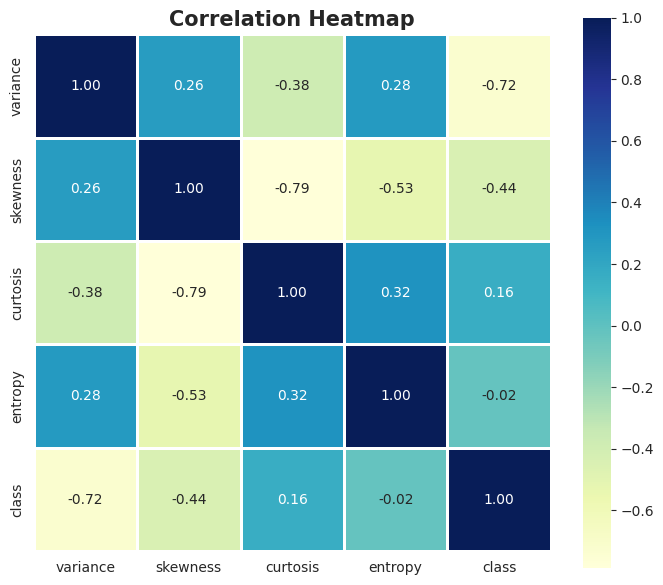

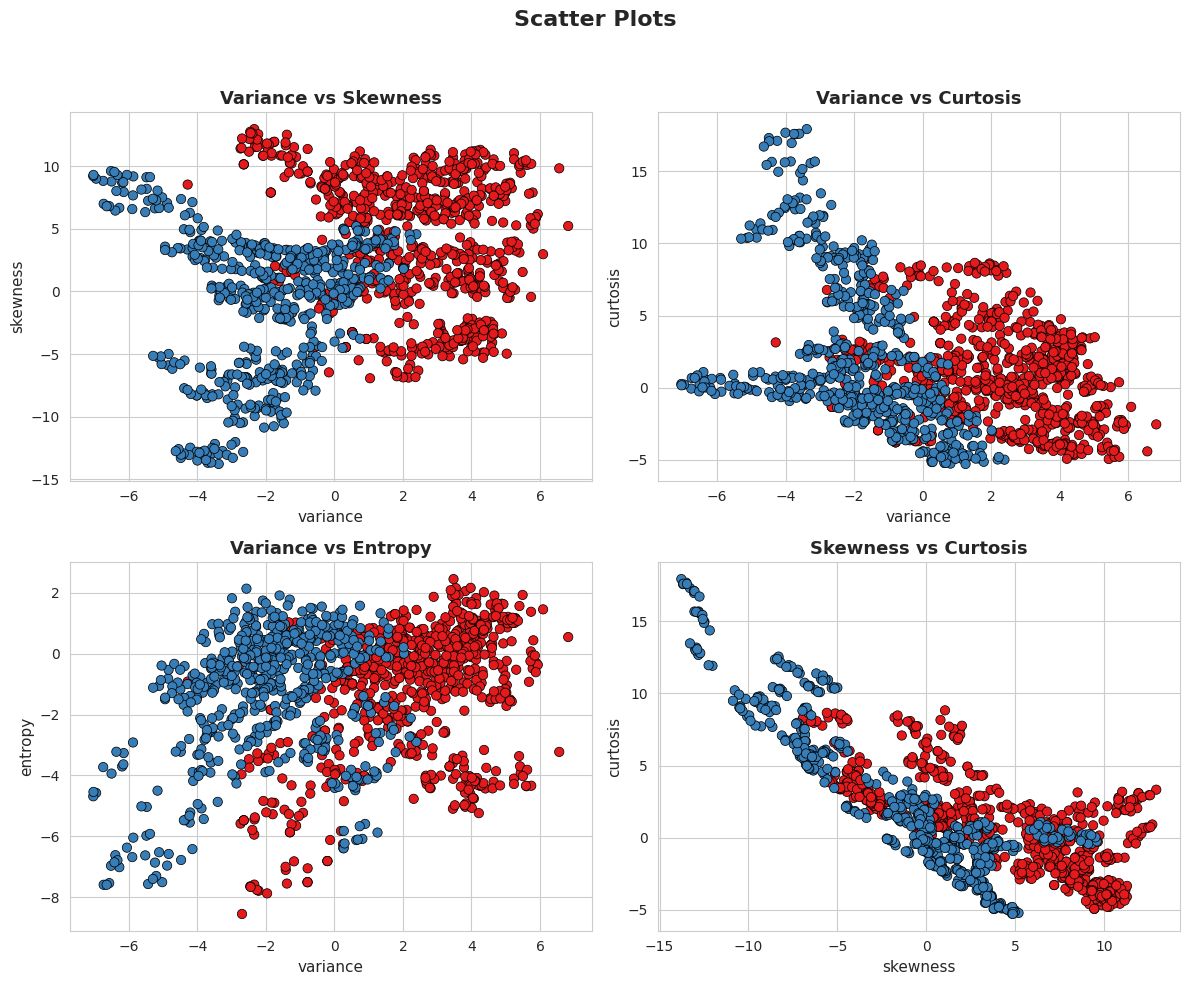

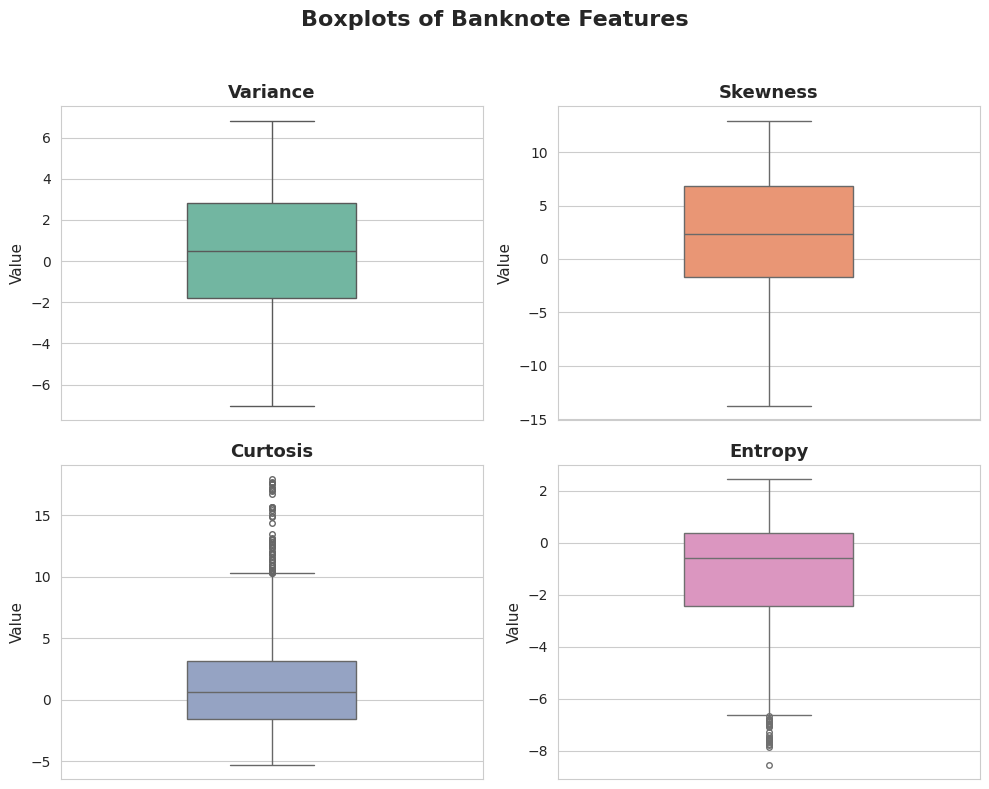

In [ ]:
# Task 2: Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

features = ["variance", "skewness", "curtosis", "entropy"]

# Histograms
hist_colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

for ax, feature, color in zip(axes, features, hist_colors):
    ax.hist(df[feature],
            bins=20,
            color=color,
            edgecolor="black"
          )
    ax.set_title(feature.capitalize(), fontweight="bold")
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Frequency")


fig.suptitle("Histograms of Banknote Features",
             fontsize=16,
             fontweight="bold")

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("histograms.eps", dpi=600, format="eps")
plt.show()

# Correlation Heatmap
fig, ax = plt.subplots(figsize=(7,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="YlGnBu",
            linewidths=1,
            square=True,
            fmt=".2f",
            annot_kws={"size":10},
            cbar=True,
            ax=ax)

ax.set_title("Correlation Heatmap",
             fontsize=15,
             fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_heatmap.eps",
            dpi=600,
            format="eps")
plt.show()

# Scatter Plots
scatter_pairs = [
    ("variance","skewness"),
    ("variance","curtosis"),
    ("variance","entropy"),
    ("skewness","curtosis")
]

fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for ax, (x, y) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="class",
        palette="Set1",
        s=45,
        edgecolor="black",
        legend=False,
        ax=ax
    )

    ax.set_title(f"{x.capitalize()} vs {y.capitalize()}",
                 fontweight="bold")

fig.suptitle("Scatter Plots",
             fontsize=16,
             fontweight="bold")

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("scatterplots.eps",
            dpi=600,
            format="eps")
plt.show()

# Boxplots
box_colors = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3"]

fig, axes = plt.subplots(2,2, figsize=(10,8))
axes = axes.flatten()

for ax, feature, color in zip(axes, features, box_colors):

    sns.boxplot(
        y=df[feature],
        color=color,
        width=0.4,
        fliersize=4,
        ax=ax
    )

    ax.set_title(feature.capitalize(),
                 fontweight="bold")
    ax.set_ylabel("Value")

fig.suptitle("Boxplots of Banknote Features",
             fontsize=16,
             fontweight="bold")

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("boxplots.eps",
            dpi=600,
            format="eps")
plt.show()

In [ ]:
# Task 3: Data Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("class", axis=1)
y = df["class"]

# Normalize numerical features
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame (optional)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print("First 5 rows of Normalized Features:")
print(X_normalized.head())

# Split the dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print("\nTraining Set Shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Set Shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

First 5 rows of Normalized Features:
   variance  skewness  curtosis   entropy
0  0.769004  0.839643  0.106783  0.736628
1  0.835659  0.820982  0.121804  0.644326
2  0.786629  0.416648  0.310608  0.786951
3  0.757105  0.871699  0.054921  0.450440
4  0.531578  0.348662  0.424662  0.687362

Training Set Shape:
X_train: (1097, 4)
y_train: (1097,)

Testing Set Shape:
X_test: (275, 4)
y_test: (275,)


In [ ]:
# Task 4: Perceptron Implementation (From Scratch)
import numpy as np
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs

        # Weight Initialization
        self.weights = None

        # Bias Initialization
        self.bias = None

    # Step Activation Function
    def step_activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    # Forward Propagation
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.step_activation(linear_output)

    # Perceptron Learning Rule (Training)
    def fit(self, X, y):

        # Number of samples and features
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Training
        for epoch in range(self.epochs):

            for i in range(n_samples):

                # Forward Propagation
                prediction = self.predict(X[i])

                # Calculate Error
                error = y[i] - prediction

                # Update Weights
                self.weights = self.weights + self.learning_rate * error * X[i]

                # Update Bias
                self.bias = self.bias + self.learning_rate * error

        print("Training Completed")
        print("\nFinal Weights:")
        print(self.weights)

        print("\nFinal Bias:")
        print(self.bias)

# Prepare Data
X_train_np = X_train.values
X_test_np = X_test.values

y_train_np = y_train.values.ravel()
y_test_np = y_test.values.ravel()

# Create and Train Perceptron
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(X_train_np, y_train_np)

# Test the Model
y_pred = []

for sample in X_test_np:
    prediction = perceptron.predict(sample)
    y_pred.append(prediction)

y_pred = np.array(y_pred)

# Display Predictions
print("\nFirst 10 Actual Labels:")
print(y_test_np[:10])

print("\nFirst 10 Predicted Labels:")
print(y_pred[:10])

Training Completed

Final Weights:
[-0.212646   -0.22344583 -0.2247334  -0.00668588]

Final Bias:
0.2900000000000001

First 10 Actual Labels:
[0 1 0 1 1 1 0 0 0 1]

First 10 Predicted Labels:
[0 1 0 1 1 1 0 0 0 1]


In [ ]:
# Task 5: Model Training

# Convert to NumPy arrays
X_train_np = X_train.values
y_train_np = y_train.values.ravel()

# Create Perceptron
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=20
)

# Initialize weights and bias
n_samples, n_features = X_train_np.shape
perceptron.weights = np.zeros(n_features)
perceptron.bias = 0

# Training
for epoch in range(perceptron.epochs):

    misclassified = 0

    for i in range(n_samples):

        prediction = perceptron.predict(X_train_np[i])

        error = y_train_np[i] - prediction

        if error != 0:
            misclassified += 1

        # Update weights
        perceptron.weights += (
            perceptron.learning_rate *
            error *
            X_train_np[i]
        )

        # Update bias
        perceptron.bias += (
            perceptron.learning_rate *
            error
        )

    print(f"\nEpoch {epoch+1}")
    print(f"Misclassified Samples : {misclassified}")
    print(f"Updated Weights : {perceptron.weights}")
    print(f"Updated Bias : {perceptron.bias}")

    # Stop if converged
    if misclassified == 0:
        print("\nTraining Converged!")
        break


Epoch 1
Misclassified Samples : 171
Updated Weights : [-0.06792364 -0.04617278 -0.05904233  0.02213631]
Updated Bias : 0.07

Epoch 2
Misclassified Samples : 101
Updated Weights : [-0.08380509 -0.06774466 -0.08105979  0.00775587]
Updated Bias : 0.09999999999999999

Epoch 3
Misclassified Samples : 43
Updated Weights : [-0.08780541 -0.07827122 -0.08945257  0.00240271]
Updated Bias : 0.10999999999999999

Epoch 4
Misclassified Samples : 43
Updated Weights : [-0.09081985 -0.08978894 -0.09123274  0.00439111]
Updated Bias : 0.11999999999999998

Epoch 5
Misclassified Samples : 57
Updated Weights : [-0.09878964 -0.09827279 -0.09836367  0.0110804 ]
Updated Bias : 0.12999999999999998

Epoch 6
Misclassified Samples : 43
Updated Weights : [-0.0971687  -0.10179894 -0.10908865  0.0144443 ]
Updated Bias : 0.13999999999999999

Epoch 7
Misclassified Samples : 30
Updated Weights : [-0.11075321 -0.10405292 -0.11086234  0.00277833]
Updated Bias : 0.13999999999999999

Epoch 8
Misclassified Samples : 49
Upda

Model Evaluation
Accuracy  : 0.9855
Precision : 0.9683
Recall    : 1.0000
F1-Score  : 0.9839

Confusion Matrix:
[[149   4]
 [  0 122]]


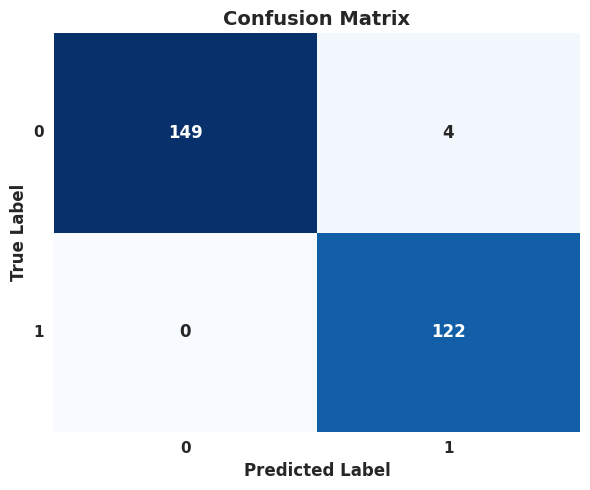

In [ ]:
# Task 6: Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Convert test data to NumPy arrays
X_test_np = X_test.values
y_test_np = y_test.values.ravel()

# Predict on test set
y_pred = []

for sample in X_test_np:
    prediction = perceptron.predict(sample)
    y_pred.append(prediction)

# Evaluation Metrics
accuracy = accuracy_score(y_test_np, y_pred)
precision = precision_score(y_test_np, y_pred)
recall = recall_score(y_test_np, y_pred)
f1 = f1_score(y_test_np, y_pred)

print("Model Evaluation")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    annot_kws={"fontsize":12, "fontweight":"bold"}
)

# Bold title and axis labels
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=12, fontweight='bold')

# Make tick labels bold
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold', rotation=0)

plt.tight_layout()

# Save as EPS (600 dpi)
plt.savefig("confusion_matrix.eps", format="eps", dpi=600)

plt.show()

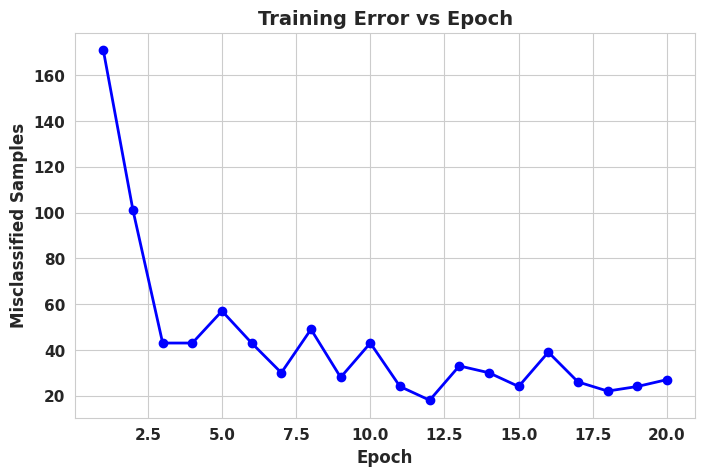

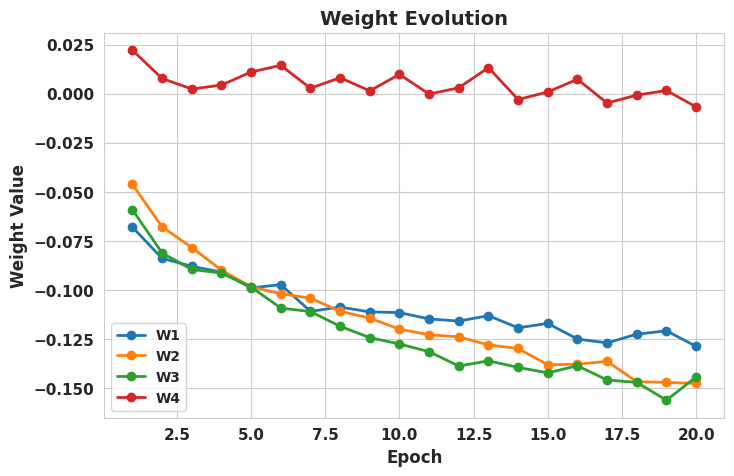

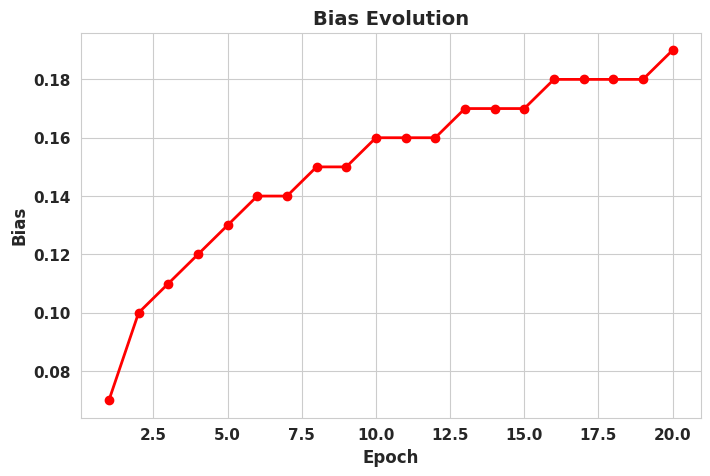

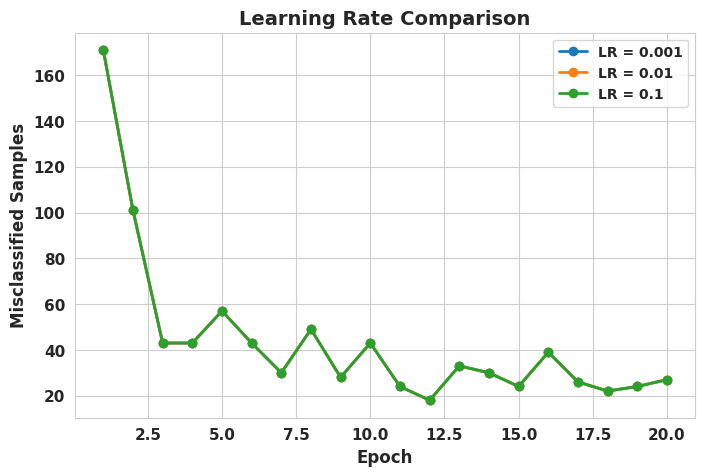

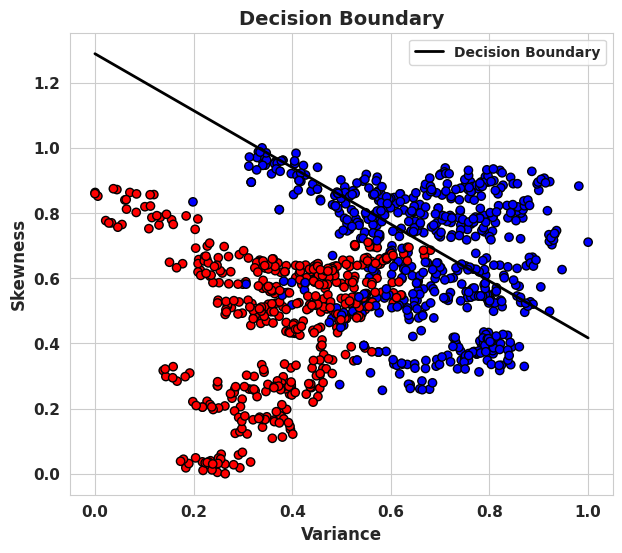

In [ ]:
# Mandatory plots

import numpy as np
import matplotlib.pyplot as plt

# Re-train Perceptron while storing history
learning_rate = 0.01
epochs = 20

perceptron = Perceptron(
    learning_rate=learning_rate,
    epochs=epochs
)

n_samples, n_features = X_train_np.shape

perceptron.weights = np.zeros(n_features)
perceptron.bias = 0

training_errors = []
weight_history = []
bias_history = []

for epoch in range(epochs):

    misclassified = 0

    for i in range(n_samples):

        prediction = perceptron.predict(X_train_np[i])

        error = y_train_np[i] - prediction

        if error != 0:
            misclassified += 1

        perceptron.weights += learning_rate * error * X_train_np[i]
        perceptron.bias += learning_rate * error

    training_errors.append(misclassified)
    weight_history.append(perceptron.weights.copy())
    bias_history.append(perceptron.bias)

    if misclassified == 0:
        break

# Training Error vs Epoch

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(training_errors)+1),
    training_errors,
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title("Training Error vs Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Misclassified Samples", fontsize=12, fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.grid(True)

plt.savefig("training_error_vs_epoch.eps",
            format="eps",
            dpi=600)

plt.show()


# Weight Evolution

weights = np.array(weight_history)

plt.figure(figsize=(8,5))

for i in range(weights.shape[1]):
    plt.plot(
        range(1, len(weights)+1),
        weights[:, i],
        marker='o',
        linewidth=2,
        label=f"W{i+1}"
    )

plt.title("Weight Evolution", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Weight Value", fontsize=12, fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

legend = plt.legend()
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.grid(True)

plt.savefig("weight_evolution.eps",
            format="eps",
            dpi=600)

plt.show()


# Bias Evolution

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(bias_history)+1),
    bias_history,
    marker='o',
    linewidth=2,
    color='red'
)

plt.title("Bias Evolution", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Bias", fontsize=12, fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.grid(True)

plt.savefig("bias_evolution.eps",
            format="eps",
            dpi=600)

plt.show()


# Learning Rate Comparison
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=20
    )

    model.weights = np.zeros(n_features)
    model.bias = 0

    errors = []

    for epoch in range(20):

        misclassified = 0

        for i in range(n_samples):

            prediction = model.predict(X_train_np[i])

            error = y_train_np[i] - prediction

            if error != 0:
                misclassified += 1

            model.weights += lr * error * X_train_np[i]
            model.bias += lr * error

        errors.append(misclassified)

        if misclassified == 0:
            break

    plt.plot(
        range(1, len(errors)+1),
        errors,
        marker='o',
        linewidth=2,
        label=f"LR = {lr}"
    )

plt.title("Learning Rate Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Misclassified Samples", fontsize=12, fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

legend = plt.legend()
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.grid(True)

plt.savefig("learning_rate_comparison.eps",
            format="eps",
            dpi=600)

plt.show()


# Decision Boundary

plt.figure(figsize=(7,6))

# Solid colors (avoids EPS transparency warning)
colors = ['blue' if label == 0 else 'red' for label in y_train_np]

plt.scatter(
    X_train_np[:,0],
    X_train_np[:,1],
    c=colors,
    edgecolors='black'
)

x = np.linspace(
    X_train_np[:,0].min(),
    X_train_np[:,0].max(),
    100
)

w = perceptron.weights
b = perceptron.bias

y = -(w[0]*x + b)/w[1]

plt.plot(
    x,
    y,
    color='black',
    linewidth=2,
    label='Decision Boundary'
)

plt.title("Decision Boundary", fontsize=14, fontweight='bold')
plt.xlabel("Variance", fontsize=12, fontweight='bold')
plt.ylabel("Skewness", fontsize=12, fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

legend = plt.legend()
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.savefig("decision_boundary.eps",
            format="eps",
            dpi=600)

plt.show()

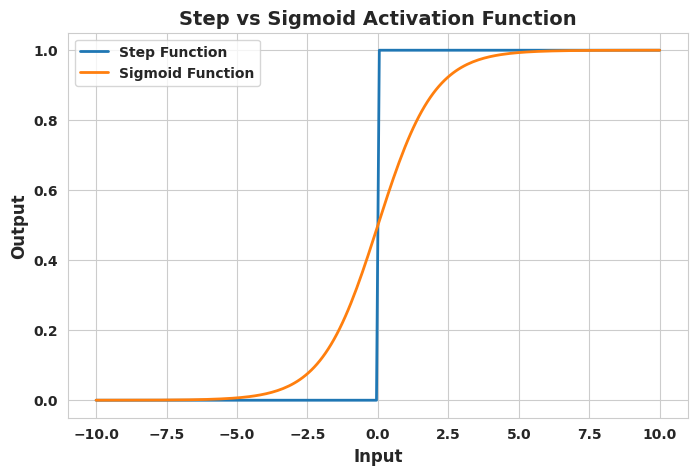

Scikit-learn Perceptron
Scikit-learn Accuracy : 0.9709


Learning Rate Comparison
Training Completed

Final Weights:
[-0.0128552  -0.01474075 -0.01441344 -0.00067307]

Final Bias:
0.01900000000000001
Learning Rate = 0.001
Accuracy      = 0.9855
------------------------------
Training Completed

Final Weights:
[-0.12855196 -0.14740746 -0.1441344  -0.00673072]

Final Bias:
0.19000000000000003
Learning Rate = 0.01
Accuracy      = 0.9855
------------------------------


Training Completed

Final Weights:
[-1.28551961 -1.47407458 -1.44134403 -0.06730724]

Final Bias:
1.9000000000000006
Learning Rate = 0.1
Accuracy      = 0.9855
------------------------------


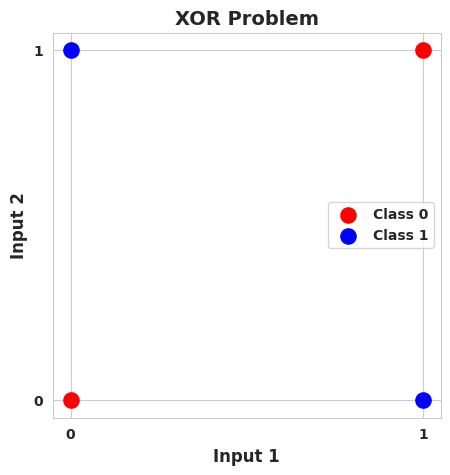



Effect of Feature Normalization
Training Completed

Final Weights:
[-0.67528821 -0.45572099 -0.5185033  -0.01774393]

Final Bias:
0.7300000000000004
Training Completed

Final Weights:
[-0.12855196 -0.14740746 -0.1441344  -0.00673072]

Final Bias:
0.19000000000000003
Accuracy without Normalization : 0.9855
Accuracy with Normalization    : 0.9855


In [ ]:
# ADDITIONAL TASKS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron as SKPerceptron
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Step vs Sigmoid Activation Function

x = np.linspace(-10, 10, 200)

step = np.where(x >= 0, 1, 0)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))

plt.plot(x, step, linewidth=2, label="Step Function")
plt.plot(x, sigmoid, linewidth=2, label="Sigmoid Function")

plt.title("Step vs Sigmoid Activation Function",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Input",
           fontsize=12,
           fontweight="bold")

plt.ylabel("Output",
           fontsize=12,
           fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(True)
plt.legend(prop={'weight':'bold'})

plt.savefig("step_vs_sigmoid.eps",
            dpi=600,
            format="eps")

plt.show()

# Compare with Scikit-learn Perceptron

print("="*60)
print("Scikit-learn Perceptron")
print("="*60)

sk_model = SKPerceptron(
    max_iter=100,
    eta0=0.01,
    random_state=42
)

sk_model.fit(X_train_np, y_train_np)

sk_pred = sk_model.predict(X_test_np)

print("Scikit-learn Accuracy :",
      round(accuracy_score(y_test_np, sk_pred),4))

# Learning Rate Comparison

print("\n")
print("="*60)
print("Learning Rate Comparison")
print("="*60)

learning_rates = [0.001,0.01,0.1]

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=20
    )

    model.fit(X_train_np, y_train_np)

    predictions = []

    for sample in X_test_np:
        predictions.append(model.predict(sample))

    accuracy = accuracy_score(
        y_test_np,
        predictions
    )

    print(f"Learning Rate = {lr}")
    print(f"Accuracy      = {accuracy:.4f}")
    print("-"*30)


# XOR Problem

X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

plt.figure(figsize=(5,5))

for i in range(len(X_xor)):

    if y_xor[i] == 0:

        plt.scatter(
            X_xor[i,0],
            X_xor[i,1],
            color="red",
            s=120,
            label="Class 0" if i==0 else ""
        )

    else:

        plt.scatter(
            X_xor[i,0],
            X_xor[i,1],
            color="blue",
            s=120,
            label="Class 1" if i==1 else ""
        )

plt.title("XOR Problem",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Input 1",
           fontsize=12,
           fontweight="bold")

plt.ylabel("Input 2",
           fontsize=12,
           fontweight="bold")

plt.xticks([0,1],fontweight="bold")
plt.yticks([0,1],fontweight="bold")

plt.grid(True)

plt.legend(prop={'weight':'bold'})

plt.savefig("xor_problem.eps",
            dpi=600,
            format="eps")

plt.show()

# Effect of Feature Normalization

print("\n")
print("="*60)
print("Effect of Feature Normalization")
print("="*60)

# ---------- WITHOUT NORMALIZATION ----------

# Recover original (unnormalized) training/testing data
X_train_original = scaler.inverse_transform(X_train_np)
X_test_original = scaler.inverse_transform(X_test_np)

model_without = Perceptron(
    learning_rate=0.01,
    epochs=20
)

model_without.fit(
    X_train_original,
    y_train_np
)

pred_without = []

for sample in X_test_original:
    pred_without.append(
        model_without.predict(sample)
    )

accuracy_without = accuracy_score(
    y_test_np,
    pred_without
)


# ---------- WITH NORMALIZATION ----------

model_with = Perceptron(
    learning_rate=0.01,
    epochs=20
)

model_with.fit(
    X_train_np,
    y_train_np
)

pred_with = []

for sample in X_test_np:
    pred_with.append(
        model_with.predict(sample)
    )

accuracy_with = accuracy_score(
    y_test_np,
    pred_with
)

print(f"Accuracy without Normalization : {accuracy_without:.4f}")
print(f"Accuracy with Normalization    : {accuracy_with:.4f}")